# Analytics Deep Dive — Medicare Denial Intelligence

Uses **dbt analytics tables** (`public_analytics.*`) built for Power BI and advanced analysis.

**Prerequisites:**
```powershell
cd dbt
dbt run --select analytics --threads 1
dbt test --select analytics
```

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
load_dotenv(PROJECT_ROOT / ".env")

engine = create_engine(
    "postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}".format(
        user=os.getenv("POSTGRES_USER", "denial_user"),
        password=os.getenv("POSTGRES_PASSWORD", ""),
        host=os.getenv("POSTGRES_HOST", "localhost"),
        port=os.getenv("POSTGRES_PORT", "5432"),
        db=os.getenv("POSTGRES_DB", "denial_db"),
    )
)

def q(sql, **params):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, params=params)

sns.set_theme(style="whitegrid")
SCHEMA = "public_analytics"

## 1. Executive KPIs

In [2]:
kpis = q(f"SELECT * FROM {SCHEMA}.anl_kpi_overview")
kpis.T

,0
provider_count,9606683
benchmark_row_count,9996
national_avg_withhold_rate,0.2148
national_median_withhold_rate,0.2093
total_part_d_cost,439430356946.710022
part_d_prescriber_count,1243554
distinct_drugs,3247
_updated_at,2026-06-24 17:21:59.410702+00:00


## 2. National withhold by specialty (2024)

In [3]:
specialty_2024 = q(f"""
SELECT specialty, weighted_avg_withhold_rate, total_services, provider_count
FROM {SCHEMA}.anl_withhold_national
WHERE year = 2024
ORDER BY weighted_avg_withhold_rate DESC
LIMIT 15
""")
specialty_2024

,specialty,weighted_avg_withhold_rate,total_services,provider_count
0,Optometry,0.3219,18990849.1,30060.0
1,Chiropractic,0.3007,16687827.1,31446.0
2,Audiologist,0.2940,2334277.0,7511.0
3,Ophthalmology,0.2747,149361318.7,17025.0
4,Maxillofacial Surgery,0.2728,64932.0,463.0
5,Oral Surgery (Dentist only),0.2661,159554.0,702.0
6,Dermatology,0.2653,49080686.5,12342.0
7,Podiatry,0.2653,29022759.2,15229.0
8,Otolaryngology,0.2638,11836092.8,8588.0
9,Sports Medicine,0.2584,7090405.4,1894.0


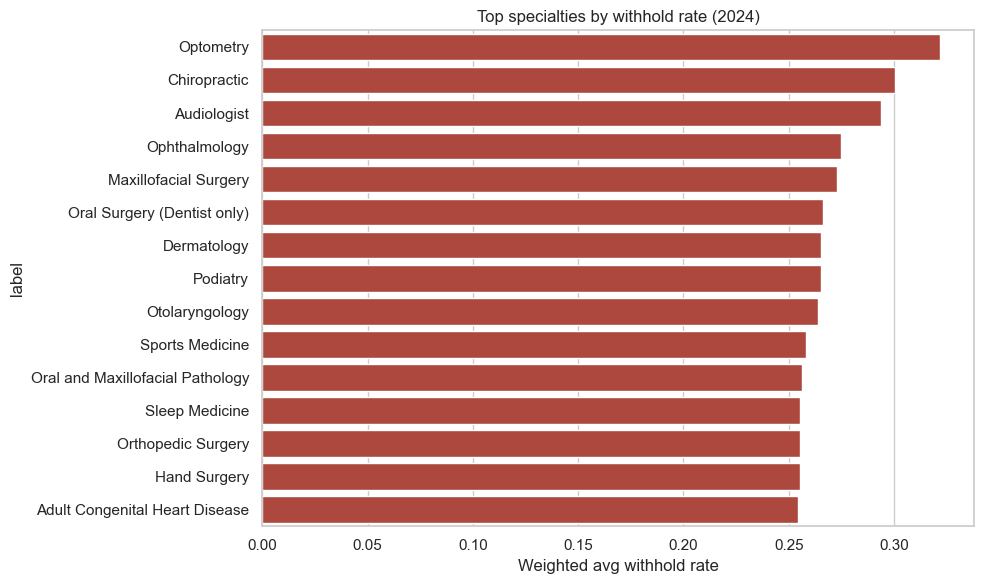

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
plot = specialty_2024.copy()
plot["label"] = plot["specialty"].str.slice(0, 40)
sns.barplot(data=plot, y="label", x="weighted_avg_withhold_rate", ax=ax, color="#c0392b")
ax.set_xlabel("Weighted avg withhold rate")
ax.set_title("Top specialties by withhold rate (2024)")
plt.tight_layout()
plt.show()

## 3. Year-over-year specialty change (2023 → 2024)

In [5]:
yoy = q(f"""
SELECT specialty, withhold_rate_2023, withhold_rate_2024,
       withhold_rate_change, withhold_rate_pct_change, service_volume_change
FROM {SCHEMA}.anl_withhold_yoy
ORDER BY withhold_rate_change DESC
LIMIT 20
""")
yoy

,specialty,withhold_rate_2023,withhold_rate_2024,withhold_rate_change,withhold_rate_pct_change,service_volume_change
0,Dental Anesthesiology,0.1016,0.1524,0.0508,0.5000,26.0
1,Preventive Medicine,0.1838,0.2024,0.0186,0.1012,18517.0
2,Medical Toxicology,0.2226,0.2379,0.0153,0.0687,-243.0
3,Emergency Medicine,0.2159,0.2298,0.0139,0.0644,425478.3
4,Certified Nurse Midwife,0.1442,0.1578,0.0136,0.0943,-798.0
5,Peripheral Vascular Disease,0.2418,0.2524,0.0106,0.0438,-4523.0
6,Pediatric Medicine,0.1849,0.1937,0.0088,0.0476,67918.5
7,Dentist,0.2433,0.2512,0.0079,0.0325,-23082.0
8,Endocrinology,0.1861,0.1936,0.0075,0.0403,1661319.0
9,Physician Assistant,0.2207,0.2275,0.0068,0.0308,17585572.5


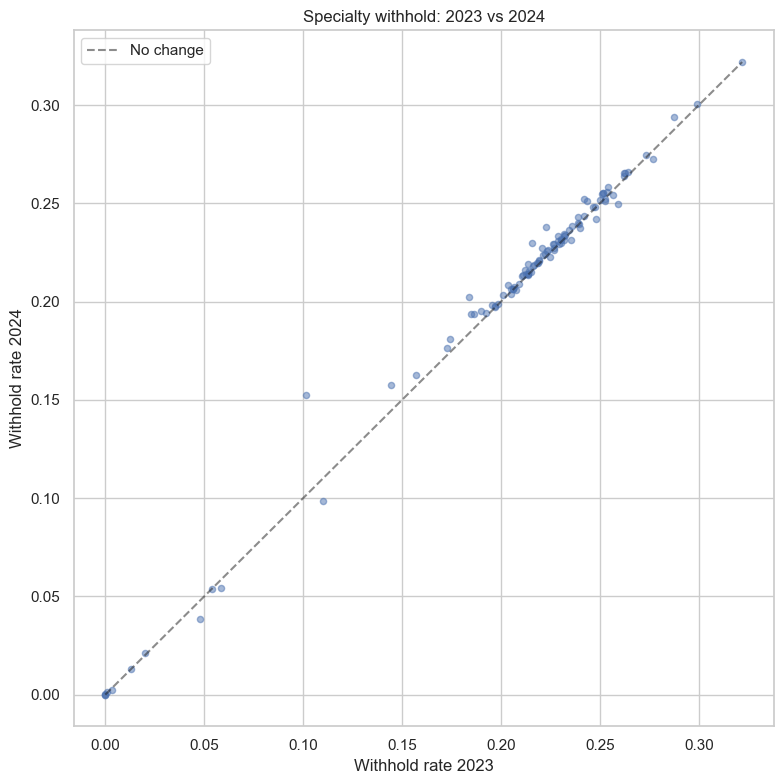

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
sample = q(f"SELECT * FROM {SCHEMA}.anl_withhold_yoy")
ax.scatter(sample["withhold_rate_2023"], sample["withhold_rate_2024"], alpha=0.5, s=20)
lims = [0, max(sample["withhold_rate_2023"].max(), sample["withhold_rate_2024"].max())]
ax.plot(lims, lims, "k--", alpha=0.5, label="No change")
ax.set_xlabel("Withhold rate 2023")
ax.set_ylabel("Withhold rate 2024")
ax.set_title("Specialty withhold: 2023 vs 2024")
ax.legend()
plt.tight_layout()
plt.show()

## 4. State-level geographic patterns

In [7]:
by_state = q(f"""
SELECT state, year, weighted_avg_withhold_rate, provider_count, total_services
FROM {SCHEMA}.anl_withhold_by_state
WHERE year = 2024
ORDER BY weighted_avg_withhold_rate DESC
LIMIT 15
""")
by_state

,state,year,weighted_avg_withhold_rate,provider_count,total_services
0,MARYLAND,2024,0.3753,1.0,226.0
1,HAMILTON,2024,0.3566,1.0,168.0
2,NEW MEXICO,2024,0.3296,1.0,102.0
3,TENNESSEE,2024,0.3268,2.0,4505.0
4,KUNSAN,2024,0.3119,1.0,142.0
5,MP,2024,0.3114,28.0,14594.5
6,ISRAEL,2024,0.3078,1.0,44.0
7,CLARK COUNTY,2024,0.2945,1.0,271.0
8,AS,2024,0.2943,1.0,36.0
9,VIRGINIA,2024,0.2860,1.0,174.0


## 5. Part D drug spending — Pareto (80/20)

In [8]:
drugs = q(f"""
SELECT drug_name, total_medicare_cost, total_claims, prescriber_count
FROM {SCHEMA}.anl_drug_spending
WHERE year = 2024
ORDER BY total_medicare_cost DESC
LIMIT 500
""")
drugs["cum_cost"] = drugs["total_medicare_cost"].cumsum()
drugs["cum_pct"] = drugs["cum_cost"] / drugs["total_medicare_cost"].sum()
drugs.head(10)

,drug_name,total_medicare_cost,total_claims,prescriber_count,cum_cost,cum_pct
0,Eliquis,1.987630e+10,22996543,264286,1.987630e+10,0.092725
1,Ozempic,1.237599e+10,9930484,171191,3.225229e+10,0.150461
2,Jardiance,1.067896e+10,10654599,198275,4.293125e+10,0.200280
3,Mounjaro,5.825296e+09,4694896,97208,4.875654e+10,0.227455
4,Xarelto,5.436702e+09,5888827,134291,5.419325e+10,0.252818
5,Trelegy Ellipta,4.832495e+09,5725949,97673,5.902574e+10,0.275363
6,Trulicity,4.786818e+09,3816376,101479,6.381256e+10,0.297694
7,Farxiga,4.661890e+09,5036718,112099,6.847445e+10,0.319442
8,Humira(Cf) Pen,3.795160e+09,437072,11704,7.226961e+10,0.337147
9,Revlimid,3.788010e+09,217318,5780,7.605762e+10,0.354818


Top 117 drugs (of 500 sampled) account for ~80% of cost in top-500


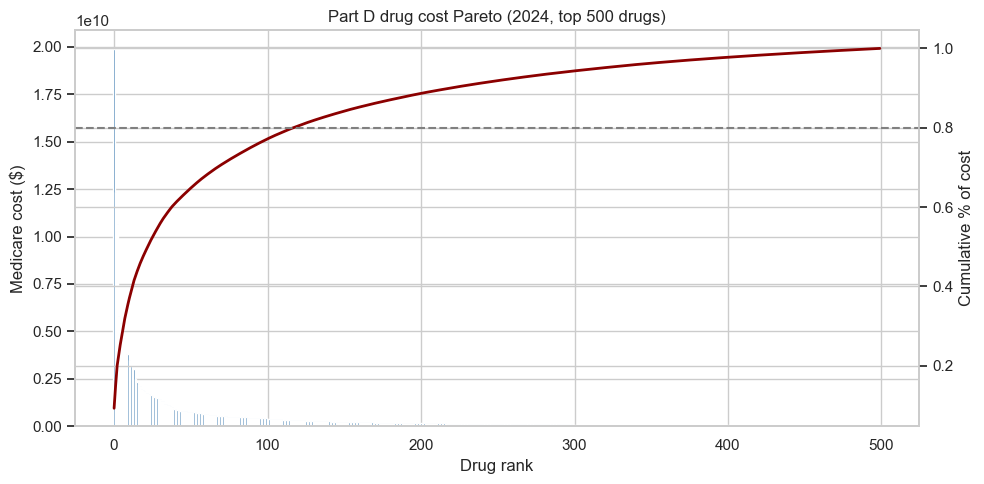

In [9]:
n_80 = (drugs["cum_pct"] <= 0.8).sum()
print(f"Top {n_80} drugs (of {len(drugs)} sampled) account for ~80% of cost in top-500")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(len(drugs)), drugs["total_medicare_cost"], color="steelblue")
ax1.set_ylabel("Medicare cost ($)")
ax1.set_xlabel("Drug rank")
ax1.set_title("Part D drug cost Pareto (2024, top 500 drugs)")
ax2 = ax1.twinx()
ax2.plot(range(len(drugs)), drugs["cum_pct"], color="darkred", linewidth=2)
ax2.axhline(0.8, color="gray", linestyle="--")
ax2.set_ylabel("Cumulative % of cost")
plt.tight_layout()
plt.show()

## 6. Provider withhold risk outliers

In [10]:
risk_summary = q(f"""
SELECT withhold_risk_band, COUNT(*) AS providers
FROM {SCHEMA}.anl_provider_withhold_risk
WHERE year = 2024
GROUP BY withhold_risk_band
ORDER BY providers DESC
""")
risk_summary

,withhold_risk_band,providers
0,High,361557
1,Low,278481
2,At Median,32822


In [11]:
high_risk = q(f"""
SELECT npi, provider_name, cms_specialty, provider_state,
       avg_withhold_rate, specialty_median_withhold, withhold_vs_median
FROM {SCHEMA}.anl_provider_withhold_risk
WHERE year = 2024 AND withhold_risk_band = 'High'
ORDER BY withhold_vs_median DESC
LIMIT 20
""")
high_risk

,npi,provider_name,cms_specialty,provider_state,avg_withhold_rate,specialty_median_withhold,withhold_vs_median
0,1538734363,COURTNEY COBLER,Physical Therapist in Private Practice,AZ,0.9243,0.2286,0.6957
1,1982668547,JULIE LEDERMAN,Nurse Practitioner,WI,0.8400,0.2190,0.6210
2,1033291919,KENNETH LEE,Ophthalmology,HI,0.8791,0.2651,0.6140
3,1114969813,1114969813,Physician Assistant,None,0.8456,0.2378,0.6078
4,1831152446,DAVID O'DONNELL,Dermatology,MI,0.8592,0.2541,0.6051
5,1346262276,FRANK MACALUSO,Diagnostic Radiology,CA,0.8284,0.2406,0.5878
6,1730457250,CALLIE POWELL,Nurse Practitioner,SC,0.7954,0.2190,0.5764
7,1619925708,CHANTELLE GASTINGER,Physician Assistant,PA,0.7926,0.2378,0.5548
8,1003441288,ERVIN XHUFKA,Nurse Practitioner,CA,0.7672,0.2190,0.5482
9,1689712994,TERESA DAVIDSON,Physician Assistant,NC,0.7626,0.2378,0.5248


## 7. Key insights (template)

Fill in after running all cells:

1. **Highest-withhold specialties (2024):** ...
2. **Biggest YoY deterioration:** ...
3. **States with elevated withhold:** ...
4. **Drug spending concentration:** Top N drugs = ~X% of cost
5. **High-risk providers:** ~X% of provider-years above specialty median

Use these bullets in README / Power BI report subtitles.